In [3]:
import torch
import torch.nn as nn
import os    
os.environ['KMP_DUPLICATE_LIB_OK'] = "True"
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
x = torch.linspace(0,799,800)

In [5]:
y = torch.sin(x*2*3.14/40)

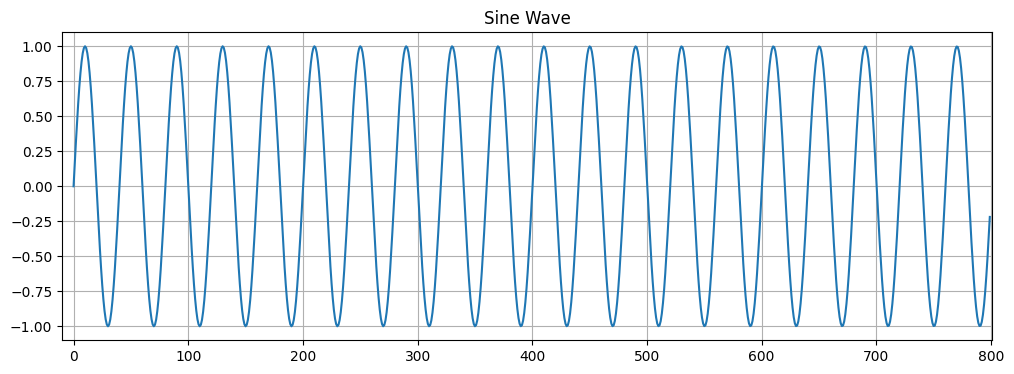

In [7]:
plt.figure(figsize=(12,4))
plt.title("Sine Wave")
plt.xlim(-10,801)
plt.grid(True)
plt.plot(y.numpy())
plt.show()

In [8]:
test_size = 40
train_set = y[:-40]
test_set = y[-40:]

In [9]:
len(train_set)

760

In [13]:
def create_batch_data(seq, ws):

    out = []
    l = len(seq)
    for i in range(l-ws):

        window = seq[i:i+ws]
        label = seq[i+ws:i+ws+1]

        out.append((window,label))

    return out

In [14]:
window_size = 40
train_data = create_batch_data(train_set, window_size)

In [18]:
train_data[0]

(tensor([ 0.0000,  0.1564,  0.3089,  0.4538,  0.5875,  0.7068,  0.8087,  0.8908,
          0.9509,  0.9876,  1.0000,  0.9878,  0.9514,  0.8915,  0.8097,  0.7080,
          0.5888,  0.4552,  0.3104,  0.1579,  0.0016, -0.1548, -0.3074, -0.4524,
         -0.5862, -0.7057, -0.8078, -0.8900, -0.9504, -0.9873, -1.0000, -0.9881,
         -0.9518, -0.8922, -0.8106, -0.7091, -0.5901, -0.4566, -0.3119, -0.1595]),
 tensor([-0.0032]))

In [19]:
class LSTM(nn.Module):

    def __init__(self, input_size=1, hidden_size=50, output_size = 1):

        super().__init__()
        
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size)
        self.linear = nn.Linear(hidden_size, output_size)

        self.hidden = (torch.zeros(1,1,hidden_size), torch.zeros(1,1,hidden_size))

    def forward(self, seq):

        lstm_out, self.hidden = self.lstm(seq.view(len(seq),1,-1), self.hidden)
        pred = self.linear(lstm_out.view(len(seq),-1))

        return pred[-1]

In [22]:
torch.manual_seed(42)
model = LSTM()
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.01)

In [23]:
model

LSTM(
  (lstm): LSTM(1, 50)
  (linear): Linear(in_features=50, out_features=1, bias=True)
)

Epoch:  1 Loss: 0.00022187
Loss on test predictions: 0.00398780032992363


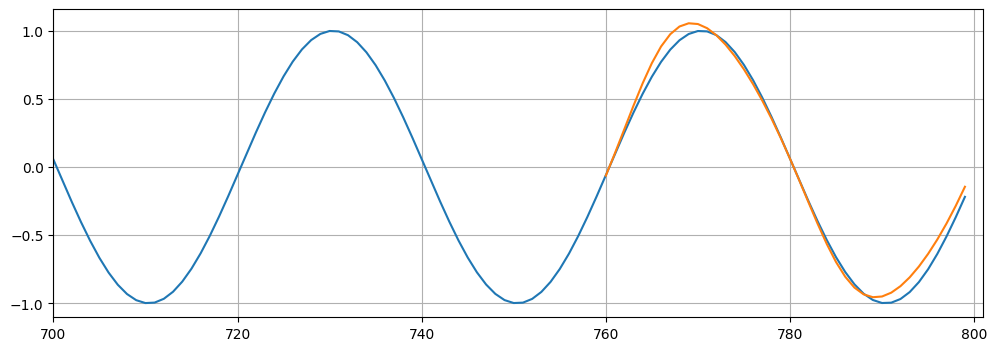

Epoch:  2 Loss: 0.00021221
Loss on test predictions: 0.0037491177208721638


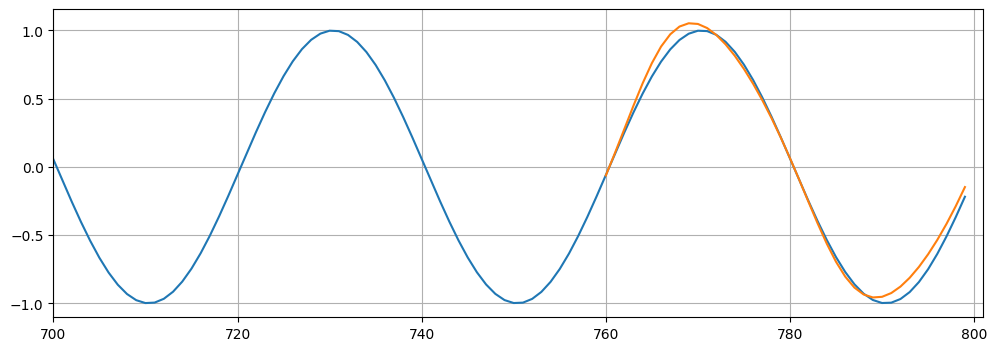

Epoch:  3 Loss: 0.00020286
Loss on test predictions: 0.0035421582870185375


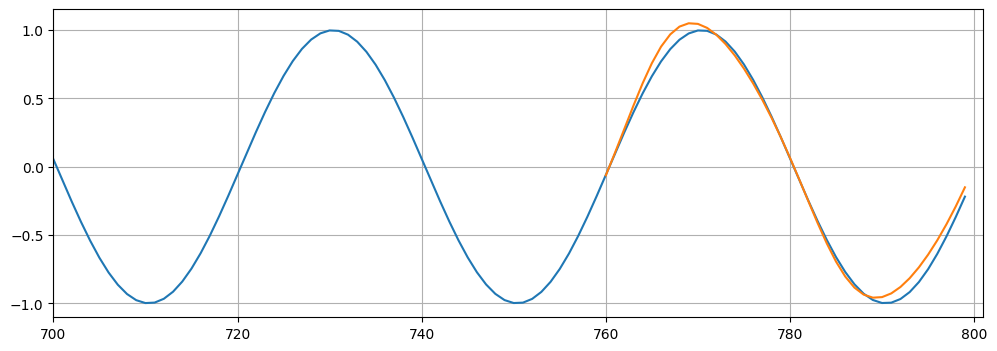

Epoch:  4 Loss: 0.00019388
Loss on test predictions: 0.00336158717982471


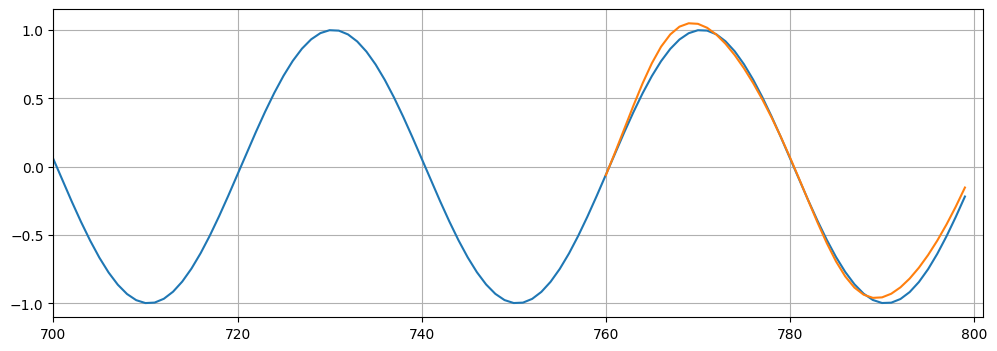

Epoch:  5 Loss: 0.00018533
Loss on test predictions: 0.003203109372407198


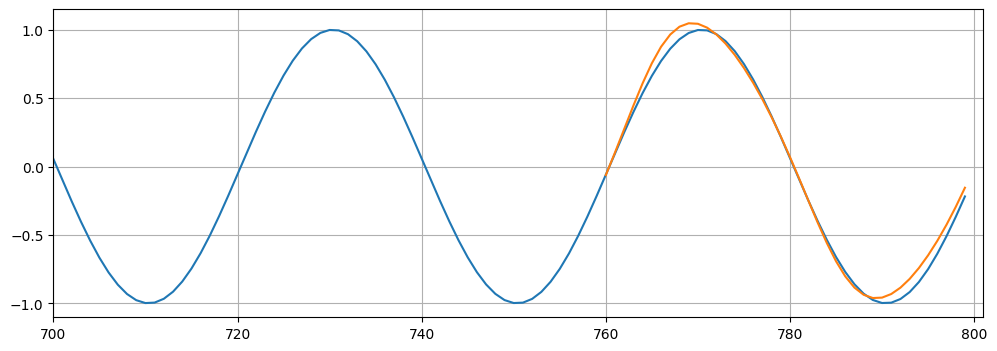

Epoch:  6 Loss: 0.00017720
Loss on test predictions: 0.0030631772242486477


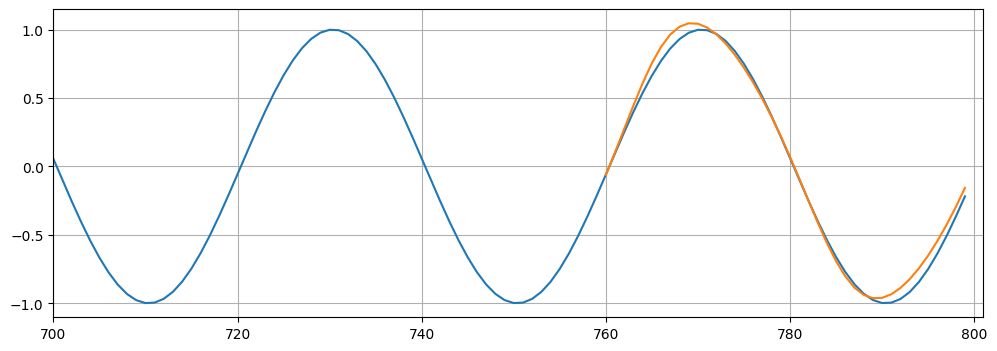

Epoch:  7 Loss: 0.00016952
Loss on test predictions: 0.00293897301889956


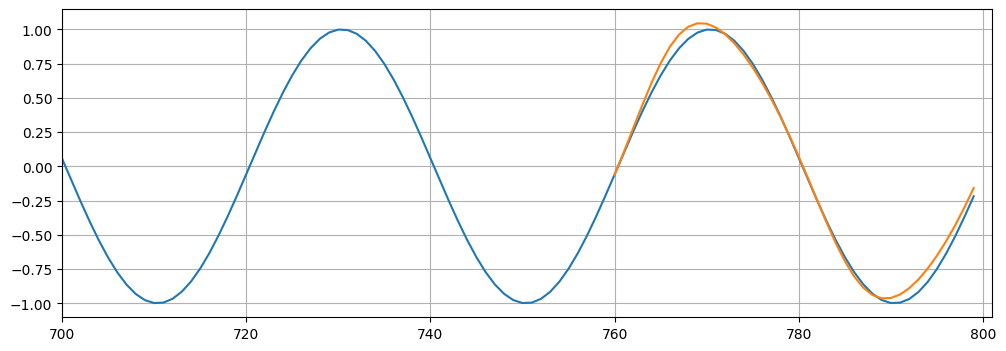

Epoch:  8 Loss: 0.00016228
Loss on test predictions: 0.0028282010462135077


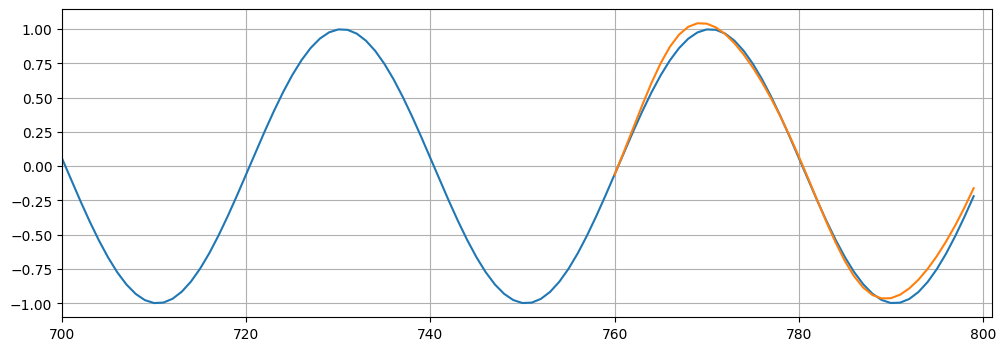

Epoch:  9 Loss: 0.00015546
Loss on test predictions: 0.002728917170315981


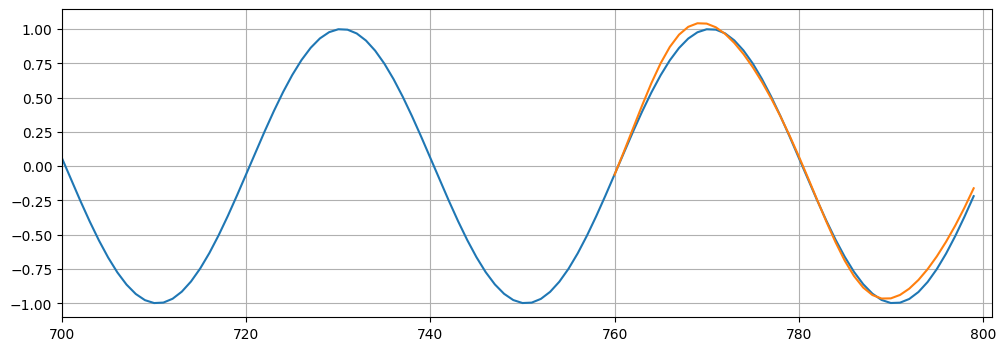

Epoch: 10 Loss: 0.00014904
Loss on test predictions: 0.0026394289452582598


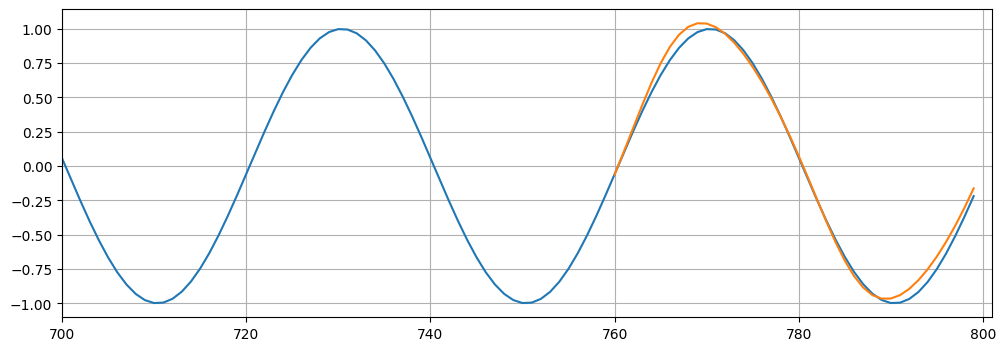

In [33]:
epochs = 10
future = 40

for i in range(epochs):

    for seq, y_train in train_data:

        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size), torch.zeros(1,1,model.hidden_size))

        y_pred = model.forward(seq)
        loss = criterion(y_pred, y_train)

        loss.backward()
        optimizer.step()
        
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')

    preds = train_set[-window_size:].tolist()

    for f in range(future):  
        seq = torch.FloatTensor(preds[-window_size:])
        with torch.no_grad():
            model.hidden = (torch.zeros(1,1,model.hidden_size),
                            torch.zeros(1,1,model.hidden_size))
            preds.append(model(seq).item())
            
    loss = criterion(torch.tensor(preds[-window_size:]),y[760:])
    print(f'Loss on test predictions: {loss}')

    # Plot from point 700 to the end
    plt.figure(figsize=(12,4))
    plt.xlim(700,801)
    plt.grid(True)
    plt.plot(y.numpy())
    plt.plot(range(760,800),preds[window_size:])
    plt.show()

In [34]:
len(train_data)

720

In [36]:
epochs = 10
window_size = 40
future = 40

# Create the full set of sequence/label tuples:
all_data = create_batch_data(y,window_size)
len(all_data)  # this should equal 800-40

760

In [37]:
import time
start_time = time.time()

for i in range(epochs):
    
    # tuple-unpack the entire set of data
    for seq, y_train in all_data:  
           
        # reset the parameters and hidden states
        optimizer.zero_grad()
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))
        
        y_pred = model(seq)
        
        loss = criterion(y_pred, y_train)
        
        loss.backward()
        optimizer.step()
        
    # print training result
    print(f'Epoch: {i+1:2} Loss: {loss.item():10.8f}')
    

Epoch:  1 Loss: 0.00014749
Epoch:  2 Loss: 0.00014139
Epoch:  3 Loss: 0.00013569
Epoch:  4 Loss: 0.00013035
Epoch:  5 Loss: 0.00012534
Epoch:  6 Loss: 0.00012065
Epoch:  7 Loss: 0.00011625
Epoch:  8 Loss: 0.00011212
Epoch:  9 Loss: 0.00010823
Epoch: 10 Loss: 0.00010457


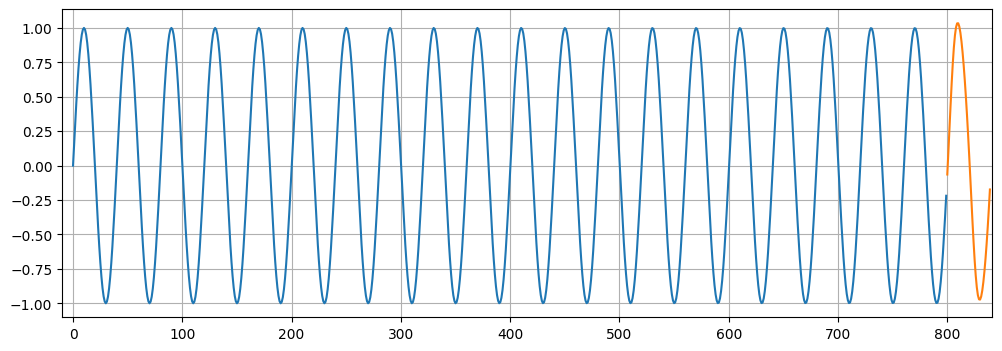

In [38]:
preds = y[-window_size:].tolist()

for i in range(future):  
    seq = torch.FloatTensor(preds[-window_size:])
    with torch.no_grad():
        # Reset the hidden parameters
        model.hidden = (torch.zeros(1,1,model.hidden_size),
                        torch.zeros(1,1,model.hidden_size))  
        preds.append(model(seq).item())

plt.figure(figsize=(12,4))
plt.xlim(-10,841)
plt.grid(True)
plt.plot(y.numpy())
plt.plot(range(800,800+future),preds[window_size:])
plt.show()